# Phase 1 notebook for the Deep Hedging project

This notebook prepares the common dataset and the full financial evaluation pipeline.
It is designed to be completed later with model outputs.


## Scope of this notebook

This notebook does three things.
It generates the common dataset.
It defines the expected format of the hedging strategies produced by the model.
It prepares the functions needed to evaluate portfolio value, hedging error, PnL and transaction-cost-adjusted PnL.


In [1]:
from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Configuration

The reference market model is a geometric Brownian motion.
The derivative is a European call option.


In [2]:
CONFIG = {
    'S0': 100.0,
    'K': 100.0,
    'T': 1.0,
    'r': 0.02,
    'sigma': 0.20,
    'N': 20,
    'n_train': 20_000,
    'n_val': 5_000,
    'n_test': 5_000,
    'option_type': 'european_call',
    'transaction_cost_rate': 0.001,
    'seed': 42,
}

BASE_DIR = Path('deep_hedging_phase1')
DATA_DIR = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'model_outputs'
RESULTS_DIR = BASE_DIR / 'results'

for folder in [DATA_DIR, OUTPUT_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

CONFIG

{'S0': 100.0,
 'K': 100.0,
 'T': 1.0,
 'r': 0.02,
 'sigma': 0.2,
 'N': 20,
 'n_train': 20000,
 'n_val': 5000,
 'n_test': 5000,
 'option_type': 'european_call',
 'transaction_cost_rate': 0.001,
 'seed': 42}

## Dataset generation

Each trajectory contains the full stock path from time 0 to maturity.
The payoff is stored separately.


In [3]:
def time_grid(T, N):
    return np.linspace(0.0, T, N + 1)


def simulate_gbm_paths(n_paths, S0, T, r, sigma, N, seed=None):
    rng = np.random.default_rng(seed)
    dt = T / N
    z = rng.standard_normal(size=(n_paths, N))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    log_paths = np.zeros((n_paths, N + 1), dtype=np.float64)
    log_paths[:, 0] = np.log(S0)
    log_paths[:, 1:] = np.log(S0) + np.cumsum(increments, axis=1)
    return np.exp(log_paths)


def european_call_payoff(paths, K):
    return np.maximum(paths[:, -1] - K, 0.0)


In [4]:
n_total = CONFIG['n_train'] + CONFIG['n_val'] + CONFIG['n_test']

times = time_grid(CONFIG['T'], CONFIG['N'])
paths = simulate_gbm_paths(
    n_paths=n_total,
    S0=CONFIG['S0'],
    T=CONFIG['T'],
    r=CONFIG['r'],
    sigma=CONFIG['sigma'],
    N=CONFIG['N'],
    seed=CONFIG['seed'],
)
payoff = european_call_payoff(paths, CONFIG['K'])

n_train = CONFIG['n_train']
n_val = CONFIG['n_val']

dataset = {
    'config': CONFIG,
    'times': times,
    'train': {
        'paths': paths[:n_train],
        'payoff': payoff[:n_train],
    },
    'validation': {
        'paths': paths[n_train:n_train+n_val],
        'payoff': payoff[n_train:n_train+n_val],
    },
    'test': {
        'paths': paths[n_train+n_val:],
        'payoff': payoff[n_train+n_val:],
    },
}

for split in ['train', 'validation', 'test']:
    print(split, dataset[split]['paths'].shape, dataset[split]['payoff'].shape)

train (20000, 21) (20000,)
validation (5000, 21) (5000,)
test (5000, 21) (5000,)


In [5]:
with open(DATA_DIR / 'dataset.pkl', 'wb') as f:
    pickle.dump(dataset, f)

with open(DATA_DIR / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(CONFIG, f, indent=2)

np.save(DATA_DIR / 'times.npy', dataset['times'])
for split in ['train', 'validation', 'test']:
    np.save(DATA_DIR / f'{split}_paths.npy', dataset[split]['paths'])
    np.save(DATA_DIR / f'{split}_payoff.npy', dataset[split]['payoff'])

print(f'Dataset saved in {DATA_DIR.resolve()}')

Dataset saved in C:\Users\nguem\Documents\ISE_3\ISE_3\M2_SFA\SEM_II\ml_finance\projet\git\Machine-Learning-in-Finance-Project\deep_hedging_phase1\data


## Quick checks

These checks confirm that the generated paths and payoffs look reasonable.


In [7]:
dt = CONFIG['T'] / CONFIG['N']
theoretical_mean_ST = CONFIG['S0'] * np.exp(CONFIG['r'] * CONFIG['T'])

print('Mean terminal stock price:', float(paths[:, -1].mean()))
print('Theoretical mean terminal stock price:', float(theoretical_mean_ST))
print('Absolute gap:', float(abs(paths[:, -1].mean() - theoretical_mean_ST)))
print('Std terminal stock price:', float(paths[:, -1].std()))
print('Mean payoff:', float(payoff.mean()))
print('Fraction of positive payoffs:', float((payoff > 0).mean()))

Mean terminal stock price: 101.88869502901619
Theoretical mean terminal stock price: 102.02013400267558
Absolute gap: 0.13143897365938528
Std terminal stock price: 20.490131641585894
Mean payoff: 8.972909834409569
Fraction of positive payoffs: 0.4967


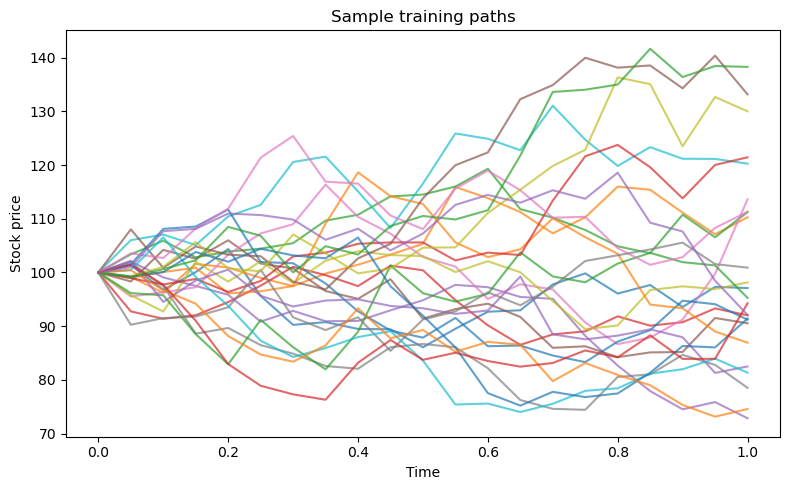

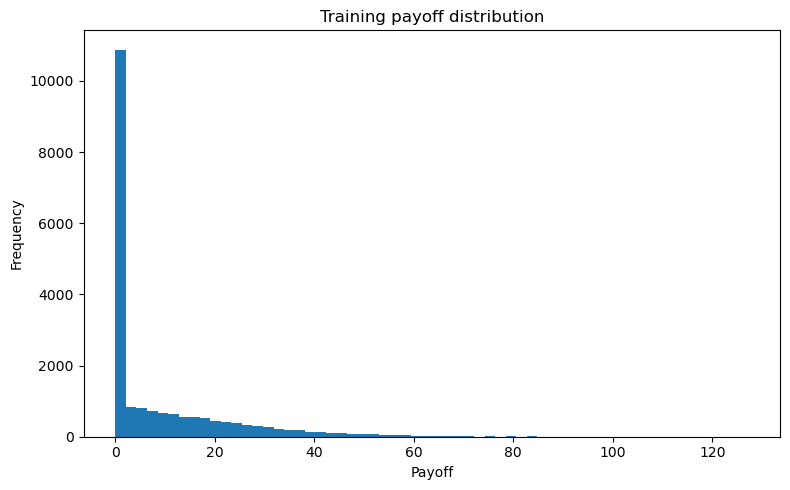

In [8]:
plt.figure(figsize=(8, 5))
for i in range(25):
    plt.plot(times, dataset['train']['paths'][i], alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Stock price')
plt.title('Sample training paths')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(dataset['train']['payoff'], bins=60)
plt.xlabel('Payoff')
plt.ylabel('Frequency')
plt.title('Training payoff distribution')
plt.tight_layout()
plt.show()

## Interface with our outputs


For a given split with `n_paths` trajectories and `N` hedging dates, the expected shape is `(n_paths, N)`.
The entry `hedges[i, t]` is the position held on interval `[t, t+1]` for trajectory `i`.


In [9]:
INTERFACE = {
    'expected_shape': '(n_paths, N)',
    'convention': 'hedges[i, t] is the hedge applied on interval [t, t+1]',
    'recommended_files': [
        'hedges_base_test.npy',
        'hedges_asymmetric_loss_test.npy',
        'hedges_transaction_cost_test.npy'
    ]
}

with open(BASE_DIR / 'interface_spec.json', 'w', encoding='utf-8') as f:
    json.dump(INTERFACE, f, indent=2)

print("Interface specification saved.")

Interface specification saved.


## Financial evaluation pipeline

The next functions can be used immediately once the hedging strategies will be availables.
They can also be tested now with a dummy strategy.


In [10]:
def validate_hedges_shape(paths, hedges):
    n_paths, n_steps_plus_one = paths.shape
    expected_shape = (n_paths, n_steps_plus_one - 1)
    if hedges.shape != expected_shape:
        raise ValueError(f'Expected hedges shape {expected_shape}, got {hedges.shape}')


def compute_portfolio_terminal_value(paths, hedges, initial_capital=0.0):
    validate_hedges_shape(paths, hedges)
    price_increments = paths[:, 1:] - paths[:, :-1]
    gains = np.sum(hedges * price_increments, axis=1)
    return initial_capital + gains


def compute_hedging_error(paths, hedges, payoff, initial_capital=0.0):
    terminal_portfolio = compute_portfolio_terminal_value(paths, hedges, initial_capital=initial_capital)
    return terminal_portfolio - payoff


def compute_transaction_costs(paths, hedges, cost_rate):
    validate_hedges_shape(paths, hedges)
    hedge_changes = np.diff(hedges, axis=1, prepend=np.zeros((hedges.shape[0], 1)))
    traded_notional = np.abs(hedge_changes) * paths[:, :-1]
    return cost_rate * np.sum(traded_notional, axis=1)


def compute_net_pnl(paths, hedges, payoff, initial_capital=0.0, cost_rate=0.0):
    terminal_portfolio = compute_portfolio_terminal_value(paths, hedges, initial_capital=initial_capital)
    costs = compute_transaction_costs(paths, hedges, cost_rate=cost_rate)
    return terminal_portfolio - payoff - costs


def summarize_array(x):
    return {
        'mean': float(np.mean(x)),
        'std': float(np.std(x)),
        'min': float(np.min(x)),
        'q01': float(np.quantile(x, 0.01)),
        'q05': float(np.quantile(x, 0.05)),
        'median': float(np.median(x)),
        'q95': float(np.quantile(x, 0.95)),
        'q99': float(np.quantile(x, 0.99)),
        'max': float(np.max(x)),
    }


def print_summary(name, x):
    summary = summarize_array(x)
    print(name)
    for k, v in summary.items():
        print(f'  {k}: {v:.6f}')
    return summary

## Dummy strategy test

This test checks that the evaluation pipeline works before receiving model outputs.
The dummy strategy used here is the zero-hedge strategy.


In [11]:
test_paths = dataset['test']['paths']
test_payoff = dataset['test']['payoff']
n_test_paths, n_steps_plus_one = test_paths.shape
N = n_steps_plus_one - 1

dummy_hedges = np.zeros((n_test_paths, N), dtype=np.float64)

dummy_error = compute_hedging_error(test_paths, dummy_hedges, test_payoff, initial_capital=0.0)
dummy_net_pnl = compute_net_pnl(
    test_paths,
    dummy_hedges,
    test_payoff,
    initial_capital=0.0,
    cost_rate=CONFIG['transaction_cost_rate']
)

summary_error = print_summary('Dummy hedging error', dummy_error)
summary_net_pnl = print_summary('Dummy net PnL', dummy_net_pnl)

Dummy hedging error
  mean: -8.536237
  std: 13.415054
  min: -97.105529
  q01: -55.085281
  q05: -37.177816
  median: 0.000000
  q95: 0.000000
  q99: 0.000000
  max: 0.000000
Dummy net PnL
  mean: -8.536237
  std: 13.415054
  min: -97.105529
  q01: -55.085281
  q05: -37.177816
  median: 0.000000
  q95: 0.000000
  q99: 0.000000
  max: 0.000000


In [12]:
with open(RESULTS_DIR / 'dummy_hedging_error_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_error, f, indent=2)

with open(RESULTS_DIR / 'dummy_net_pnl_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_net_pnl, f, indent=2)

np.save(RESULTS_DIR / 'dummy_hedging_error.npy', dummy_error)
np.save(RESULTS_DIR / 'dummy_net_pnl.npy', dummy_net_pnl)

print(f'Dummy evaluation saved in {RESULTS_DIR.resolve()}')

Dummy evaluation saved in C:\Users\nguem\Documents\ISE_3\ISE_3\M2_SFA\SEM_II\ml_finance\projet\git\Machine-Learning-in-Finance-Project\deep_hedging_phase1\results


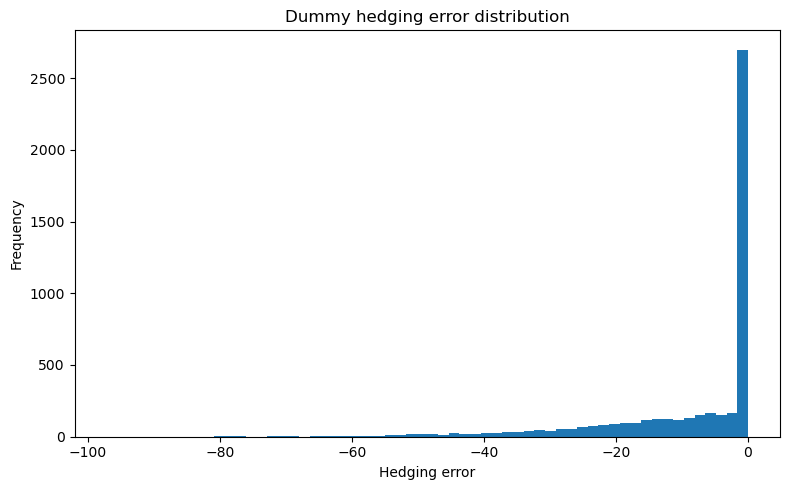

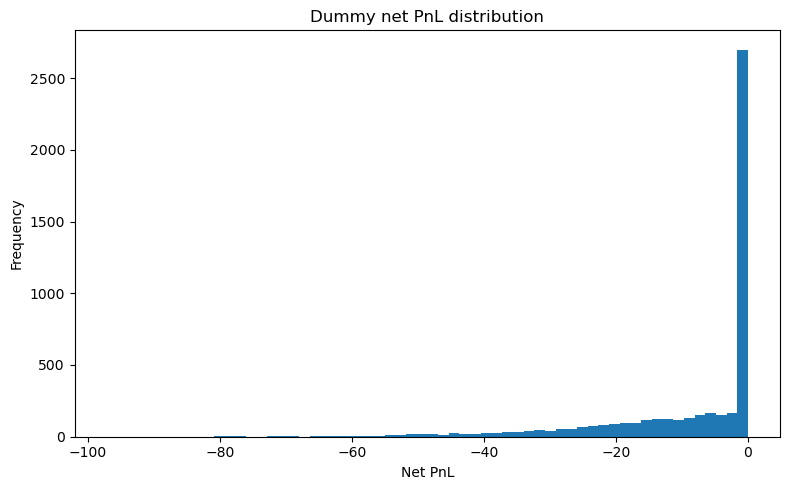

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(dummy_error, bins=60)
plt.xlabel('Hedging error')
plt.ylabel('Frequency')
plt.title('Dummy hedging error distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(dummy_net_pnl, bins=60)
plt.xlabel('Net PnL')
plt.ylabel('Frequency')
plt.title('Dummy net PnL distribution')
plt.tight_layout()
plt.show()

## Final note

At this stage, phase 1 is complete.
The dataset is ready.
The evaluation pipeline is ready.
We are waiting for hedging output.
